In [ ]:
# Cell 1: Import seluruh library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Mengaktifkan visualisasi agar muncul di dalam notebook
%matplotlib inline

In [ ]:
# Cell 2: Membaca dataset
# Ganti path sesuai dengan lokasi file dataset Anda
df = pd.read_csv("agro_environmental_dataset.csv")

# Menampilkan informasi awal struktur data
print("=== Informasi Awal Dataset ===")
print(df.info())
print(df.head())

=== Informasi Awal Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regim

In [ ]:
# Cell 3: Penanganan Missing Values dan Duplikasi
print("=== Pengecekan Missing Values ===")
print(df.isnull().sum())

print("\n=== Pengecekan Baris Duplikat ===")
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat terdeteksi: {duplicate_count}")

# Jika ada duplikat, lakukan drop (di sini tetap ditulis sebagai fungsi defensif)
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Baris duplikat berhasil dihapus.")

=== Pengecekan Missing Values ===
location_id                 0
soil_type                   0
bulk_density                0
organic_matter_pct          0
cation_exchange_capacity    0
salinity_ec                 0
buffering_capacity          0
soil_moisture_pct           0
moisture_limit_dry          0
moisture_limit_wet          0
moisture_regime             0
soil_temp_c                 0
air_temp_c                  0
thermal_regime              0
light_intensity_par         0
soil_ph                     0
ph_stress_flag              0
nitrogen_ppm                0
phosphorus_ppm              0
potassium_ppm               0
nutrient_balance            0
plant_category              0
suitability_score           0
stress_level                0
failure_flag                0
dtype: int64

=== Pengecekan Baris Duplikat ===
Jumlah baris duplikat terdeteksi: 0


In [ ]:
# Cell 4: Standardisasi kolom teks ke huruf kapital dan menghapus spasi kosong
categorical_cols = ['soil_type', 'moisture_regime', 'thermal_regime', 'plant_category']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

print("=== Contoh Hasil Pembersihan Teks ===")
print(df[categorical_cols].head())

=== Contoh Hasil Pembersihan Teks ===
  soil_type moisture_regime thermal_regime plant_category
0    CLAYEY             DRY        OPTIMAL      VEGETABLE
1  ALLUVIAL         OPTIMAL    HEAT_STRESS      VEGETABLE
2    CHALKY     WATERLOGGED    HEAT_STRESS      VEGETABLE
3     SILTY         OPTIMAL        OPTIMAL         CEREAL
4     LOAMY         OPTIMAL        OPTIMAL      VEGETABLE


In [ ]:
# Cell 5: Drop kolom penanda unik dan pemicu Data Leakage
columns_to_drop = ['location_id', 'failure_flag', 'suitability_score']

# Memastikan kolom ada sebelum dihapus
existing_drops = [col for col in columns_to_drop if col in df.columns]
df_cleaned = df.drop(columns=existing_drops)

print(f"Kolom yang berhasil dihapus untuk mencegah leakage: {existing_drops}")
print(f"Dimensi dataset sekarang: {df_cleaned.shape}")

Kolom yang berhasil dihapus untuk mencegah leakage: ['location_id', 'failure_flag', 'suitability_score']
Dimensi dataset sekarang: (543210, 22)


In [ ]:
# Cell 6: Transformasi Label Encoding
le_dict = {}
for col in categorical_cols:
    if col in df_cleaned.columns:
        le = LabelEncoder()
        df_cleaned[col] = le.fit_transform(df_cleaned[col])
        le_dict[col] = le # Menyimpan objek encoder untuk keperluan pengujian nanti

print("=== Hasil Matriks setelah Label Encoding ===")
print(df_cleaned[categorical_cols].head())

=== Hasil Matriks setelah Label Encoding ===
   soil_type  moisture_regime  thermal_regime  plant_category
0          2                0               2               2
1          0                1               1               2
2          1                2               1               2
3          8                1               2               0
4          4                1               2               2


In [ ]:
# Cell 7: Pemisahan Fitur dan Target serta Normalisasi
X = df_cleaned.drop(columns=['stress_level'])
y = df_cleaned['stress_level']

# Ambil list kolom numerik continuous untuk penskalaan
numerical_cols = X.select_dtypes(include=['float64', 'int64', 'int32']).columns

scaler = MinMaxScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("=== Deskripsi Statistik Fitur Setelah Normalisasi [0, 1] ===")
print(X.describe())

=== Deskripsi Statistik Fitur Setelah Normalisasi [0, 1] ===
           soil_type   bulk_density  organic_matter_pct  \
count  543210.000000  543210.000000       543210.000000   
mean        0.513949       0.688183            0.166685   
std         0.311956       0.270078            0.254647   
min         0.000000       0.000000            0.000000   
25%         0.250000       0.666667            0.035714   
50%         0.500000       0.666667            0.136905   
75%         0.750000       0.888889            0.154762   
max         1.000000       1.000000            1.000000   

       cation_exchange_capacity    salinity_ec  buffering_capacity  \
count             543210.000000  543210.000000       543210.000000   
mean                   0.348921       0.124696            0.517101   
std                    0.296213       0.259480            0.330965   
min                    0.000000       0.000000            0.000000   
25%                    0.085714       0.026316           

In [ ]:
print(X.dtypes)

soil_type                   float64
bulk_density                float64
organic_matter_pct          float64
cation_exchange_capacity    float64
salinity_ec                 float64
buffering_capacity          float64
soil_moisture_pct           float64
moisture_limit_dry          float64
moisture_limit_wet          float64
moisture_regime             float64
soil_temp_c                 float64
air_temp_c                  float64
thermal_regime              float64
light_intensity_par         float64
soil_ph                     float64
ph_stress_flag              float64
nitrogen_ppm                float64
phosphorus_ppm              float64
potassium_ppm               float64
nutrient_balance             object
plant_category              float64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['nutrient_balance'] = le.fit_transform(X['nutrient_balance'])

In [ ]:
# Cell 8: Penyeimbangan kelas menggunakan SMOTE
print("=== Distribusi Kelas Target Sebelum SMOTE ===")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n=== Distribusi Kelas Target Setelah SMOTE ===")
print(pd.Series(y_resampled).value_counts())

=== Distribusi Kelas Target Sebelum SMOTE ===
stress_level
1    239013
0    175267
2    128930
Name: count, dtype: int64

=== Distribusi Kelas Target Setelah SMOTE ===
stress_level
1    239013
0    239013
2    239013
Name: count, dtype: int64


In [ ]:
# Cell 9: Pengujian Seleksi Fitur
# 1. Metode Chi-Square (Mengambil 10 fitur terbaik)
best_features = SelectKBest(score_func=chi2, k=10)
fit = best_features.fit(X_resampled, y_resampled)

df_scores = pd.DataFrame(fit.scores_)
df_columns = pd.DataFrame(X_resampled.columns)

feature_scores = pd.concat([df_columns, df_scores], axis=1)
feature_scores.columns = ['Fitur', 'Skor Chi2']
print("=== Rangking Fitur Berdasarkan Chi-Square ===")
print(feature_scores.sort_values(by='Skor Chi2', ascending=False))

# Menentukan subset fitur terbaik dari Chi-Square untuk skenario optimal
top_chi_features = feature_scores.sort_values(by='Skor Chi2', ascending=False).head(10)['Fitur'].values

=== Rangking Fitur Berdasarkan Chi-Square ===
                       Fitur      Skor Chi2
19          nutrient_balance  184617.050584
15            ph_stress_flag  113495.315598
9            moisture_regime   12543.614949
4                salinity_ec   10959.950163
12            thermal_regime    9211.980990
7         moisture_limit_dry    7231.414228
5         buffering_capacity    7129.224261
3   cation_exchange_capacity    5404.922448
8         moisture_limit_wet    4672.228766
20            plant_category    3742.625017
0                  soil_type    2957.800950
2         organic_matter_pct    2889.780345
6          soil_moisture_pct    2586.509901
1               bulk_density    1603.632772
17            phosphorus_ppm     679.128185
10               soil_temp_c     508.885647
14                   soil_ph     283.727824
11                air_temp_c     257.670190
18             potassium_ppm     105.094446
16              nitrogen_ppm       1.647402
13       light_intensity_par  

In [ ]:
# Cell 10: Partisi awal data asli (Sebelum SMOTE)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("=== Ukuran Data Asli (Original) ===")
print(f"Data Latih : {X_train_raw.shape[0]} baris")
print(f"Data Uji   : {X_test_raw.shape[0]} baris")

=== Ukuran Data Asli (Original) ===
Data Latih : 434568 baris
Data Uji   : 108642 baris


In [ ]:
# Cell 11: Menerapkan SMOTE hanya pada partisi Data Latih
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)

print("=== Distribusi Kelas Target Sebelum SMOTE ===")
print(y_train_raw.value_counts())

print("\n=== Distribusi Kelas Target Setelah SMOTE ===")
print(pd.Series(y_train_smote).value_counts())

=== Distribusi Kelas Target Sebelum SMOTE ===
stress_level
1    191210
0    140214
2    103144
Name: count, dtype: int64

=== Distribusi Kelas Target Setelah SMOTE ===
stress_level
0    191210
1    191210
2    191210
Name: count, dtype: int64


In [ ]:
# Cell 12: Seleksi 10 fitur terbaik menggunakan Chi-Square
selector = SelectKBest(score_func=chi2, k=10)
selector.fit(X_train_raw, y_train_raw)

# Mengambil nama kolom fitur terbaik
top_10_features = X_train_raw.columns[selector.get_support()].tolist()

print("=== 10 Fitur Terbaik Hasil Seleksi Chi-Square ===")
for i, feature in enumerate(top_10_features, 1):
    print(f"{i}. {feature}")

=== 10 Fitur Terbaik Hasil Seleksi Chi-Square ===
1. cation_exchange_capacity
2. salinity_ec
3. buffering_capacity
4. moisture_limit_dry
5. moisture_limit_wet
6. moisture_regime
7. thermal_regime
8. ph_stress_flag
9. nutrient_balance
10. plant_category


In [ ]:
# Cell 13: Loop otomatisasi pelitihan dan evaluasi 8 Skenario
list_skenario = []

# Definisikan model dengan parameter standar
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=12, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Definisikan variasi kondisi data
kondisi_data = {
    'Baseline (No SMOTE)': {
        'X_train': X_train_raw, 'y_train': y_train_raw,
        'X_test': X_test_raw, 'y_test': y_test_raw
    },
    'Baseline (SMOTE)': {
        'X_train': X_train_smote, 'y_train': y_train_smote,
        'X_test': X_test_raw, 'y_test': y_test_raw
    },
    'Chi-Square (No SMOTE)': {
        'X_train': X_train_raw[top_10_features], 'y_train': y_train_raw,
        'X_test': X_test_raw[top_10_features], 'y_test': y_test_raw
    },
    'Chi-Square (SMOTE)': {
        'X_train': X_train_smote[top_10_features], 'y_train': y_train_smote,
        'X_test': X_test_raw[top_10_features], 'y_test': y_test_raw
    }
}

# Menjalankan pipeline evaluasi secara otomatis
no_skenario = 1
for nama_data, data in kondisi_data.items():
    for nama_model, model in models.items():
        # Training model
        model.fit(data['X_train'], data['y_train'])

        # Prediksi data uji
        y_pred = model.predict(data['X_test'])

        # Kalkulasi Metrik Evaluasi
        acc = accuracy_score(data['y_test'], y_pred) * 100
        prec = precision_score(data['y_test'], y_pred, average='macro', zero_division=0) * 100
        rec = recall_score(data['y_test'], y_pred, average='macro', zero_division=0) * 100
        f1 = f1_score(data['y_test'], y_pred, average='macro', zero_division=0) * 100

        # Simpan hasil ke list
        list_skenario.append({
            'No': no_skenario,
            'Kondisi Data': nama_data,
            'Model': nama_model,
            'Accuracy (%)': round(acc, 2),
            'Precision (%)': round(prec, 2),
            'Recall (%)': round(rec, 2),
            'F1-Score (%)': round(f1, 2)
        })
        no_skenario += 1

print("Proses komputasi 8 skenario selesai dijalankan.")

Proses komputasi 8 skenario selesai dijalankan.


In [ ]:
# Cell 14: Menampilkan tabel rangkuman hasil akhir eksperimen
df_hasil_akhir = pd.DataFrame(list_skenario)

print("============================ TABEL KOMPARASI KINERJA MODEL ============================")
display(df_hasil_akhir.set_index('No'))
print("=======================================================================================")

============================ TABEL KOMPARASI KINERJA MODEL ============================


,Kondisi Data,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
No,,,,,,
1,Baseline (No SMOTE),Decision Tree,82.22,83.56,81.99,82.68
2,Baseline (No SMOTE),Naive Bayes,62.81,62.94,65.99,63.03
3,Baseline (SMOTE),Decision Tree,82.30,82.68,85.08,82.78
4,Baseline (SMOTE),Naive Bayes,60.71,62.22,65.67,60.55
5,Chi-Square (No SMOTE),Decision Tree,81.08,83.10,80.54,81.48
6,Chi-Square (No SMOTE),Naive Bayes,59.78,59.57,63.13,59.92
7,Chi-Square (SMOTE),Decision Tree,81.04,81.38,83.28,81.55
8,Chi-Square (SMOTE),Naive Bayes,59.47,60.24,63.91,59.36


/tmp/ipykernel_454/723828875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


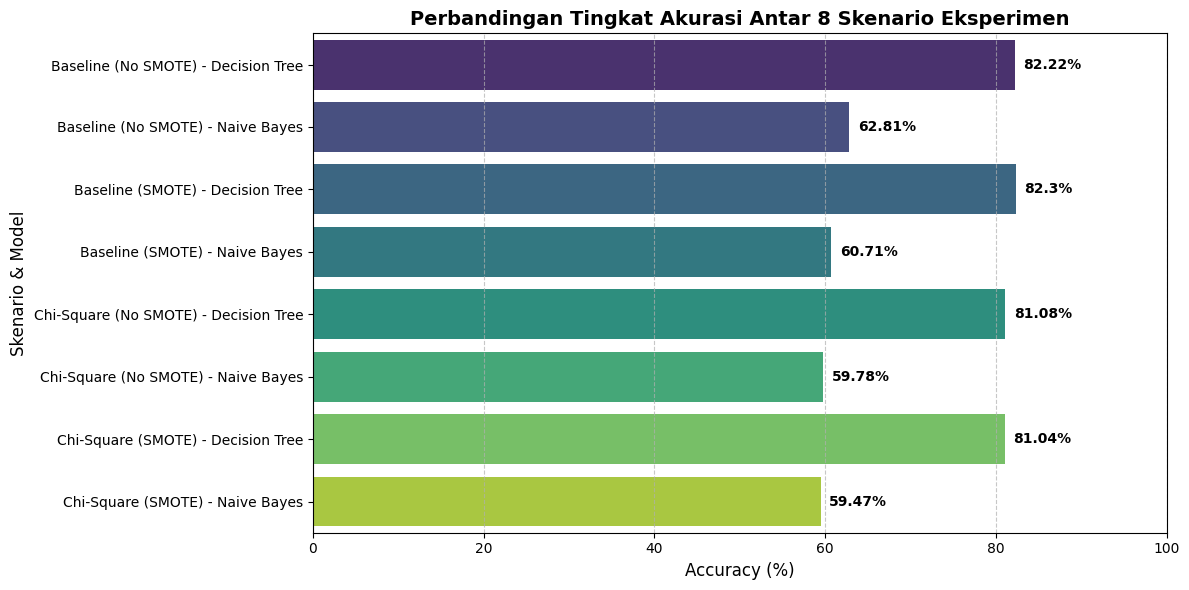

In [ ]:
# Cell 15: Visualisasi komparatif akurasi antar skenario
plt.figure(figsize=(12, 6))
df_hasil_akhir['Skenario Lengkap'] = df_hasil_akhir['Kondisi Data'] + " - " + df_hasil_akhir['Model']

sns.barplot(
    data=df_hasil_akhir,
    x='Accuracy (%)',
    y='Skenario Lengkap',
    palette='viridis'
)

plt.title('Perbandingan Tingkat Akurasi Antar 8 Skenario Eksperimen', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Skenario & Model', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Menampilkan nilai angka di ujung grafik batang
for index, value in enumerate(df_hasil_akhir['Accuracy (%)']):
    plt.text(value + 1, index, f"{value}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 10: Partisi Data Latih dan Data Uji (Perbaikan parameter test_size)
X_opt = X_resampled[top_chi_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_opt, y_resampled, test_size=0.20, stratify=y_resampled, random_state=42
)

print(f"Jumlah Data Latih (80%): {X_train.shape[0]} observasi")
print(f"Jumlah Data Uji (20%): {X_test.shape[0]} observasi")

Jumlah Data Latih (80%): 573631 observasi
Jumlah Data Uji (20%): 143408 observasi


In [ ]:
# Cell 11: Pelatihan dan Evaluasi Model Decision Tree
dt_model = DecisionTreeClassifier(max_depth=12, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# Metrik Kinerja
dt_acc = accuracy_score(y_test, y_pred_dt)
print("=== KINERJA MODEL DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))

=== KINERJA MODEL DECISION TREE ===
              precision    recall  f1-score   support

           0       0.81      0.95      0.88     47802
           1       0.79      0.68      0.73     47803
           2       0.89      0.87      0.88     47803

    accuracy                           0.83    143408
   macro avg       0.83      0.83      0.83    143408
weighted avg       0.83      0.83      0.83    143408



In [ ]:
# Cell 12: Pelatihan dan Evaluasi Model Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

# Metrik Kinerja
nb_acc = accuracy_score(y_test, y_pred_nb)
print("=== KINERJA MODEL GAUSSIAN NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb))

=== KINERJA MODEL GAUSSIAN NAIVE BAYES ===
              precision    recall  f1-score   support

           0       0.76      0.80      0.78     47802
           1       0.51      0.34      0.41     47803
           2       0.60      0.76      0.67     47803

    accuracy                           0.63    143408
   macro avg       0.62      0.63      0.62    143408
weighted avg       0.62      0.63      0.62    143408



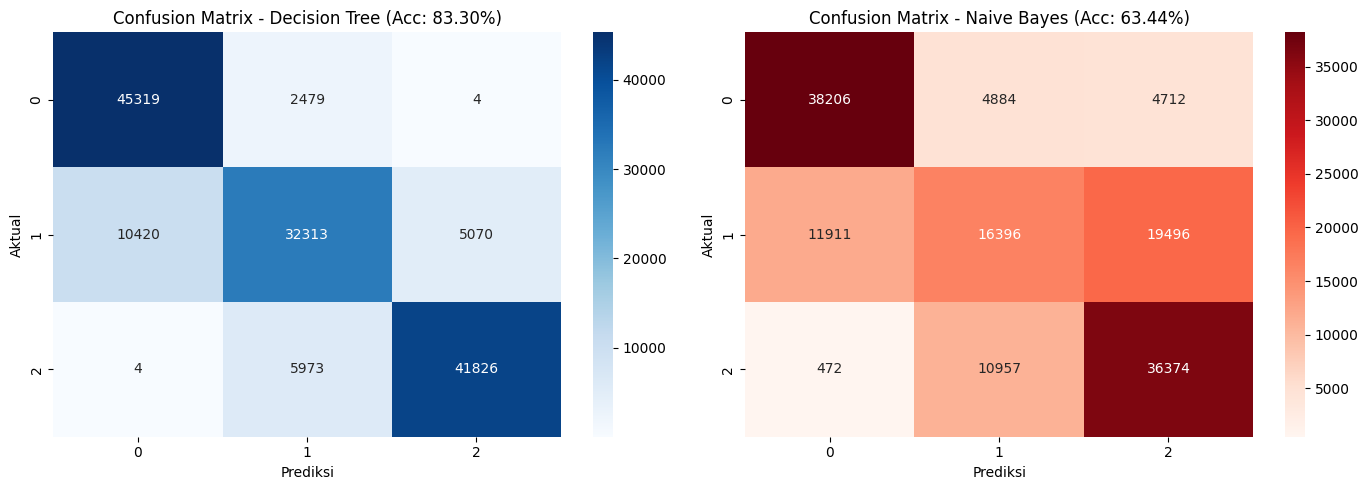

In [ ]:
# Cell 13: Visualisasi Perbandingan Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Confusion Matrix - Decision Tree (Acc: {dt_acc*100:.2f}%)')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', ax=ax[1])
ax[1].set_title(f'Confusion Matrix - Naive Bayes (Acc: {nb_acc*100:.2f}%)')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 14: Simulasi Pengujian Model (Single & Batch Testing)

print("=== 1. SIMULASI SINGLE TESTING ===")
# Membuat 1 data instans baru tiruan (pastikan jumlah fitur sesuai top_chi_features)
single_sample = [X_test.iloc[0].values]
single_pred = dt_model.predict(single_sample)
print(f"Input Atribut: {single_sample}")
print(f"Hasil Klasifikasi Prediksi Model: Kelas {single_pred[0]}")


print("\n=== 2. SIMULASI BATCH TESTING ===")
# Menguji 100 data uji sekaligus secara massal
batch_samples = X_test.head(100)
batch_preds = dt_model.predict(batch_samples)

df_batch_res = pd.DataFrame({
    'Index Aktual': batch_samples.index,
    'Hasil Prediksi Model': batch_preds
})
print("Distribusi Hasil Prediksi Massal (100 Data Pertama):")
print(df_batch_res['Hasil Prediksi Model'].value_counts())
print("\n5 Sampel Pertama Hasil Prediksi Batch:")
print(df_batch_res.head())

=== 1. SIMULASI SINGLE TESTING ===
Input Atribut: [array([2.        , 0.        , 1.        , 0.07894737, 1.        ,
       0.77272727, 1.        , 0.71428571, 0.64864865, 0.        ])]
Hasil Klasifikasi Prediksi Model: Kelas 1

=== 2. SIMULASI BATCH TESTING ===
Distribusi Hasil Prediksi Massal (100 Data Pertama):
Hasil Prediksi Model
0    38
2    32
1    30
Name: count, dtype: int64

5 Sampel Pertama Hasil Prediksi Batch:
   Index Aktual  Hasil Prediksi Model
0        289177                     1
1        111371                     1
2        348075                     0
3        434230                     0
4        608543                     2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


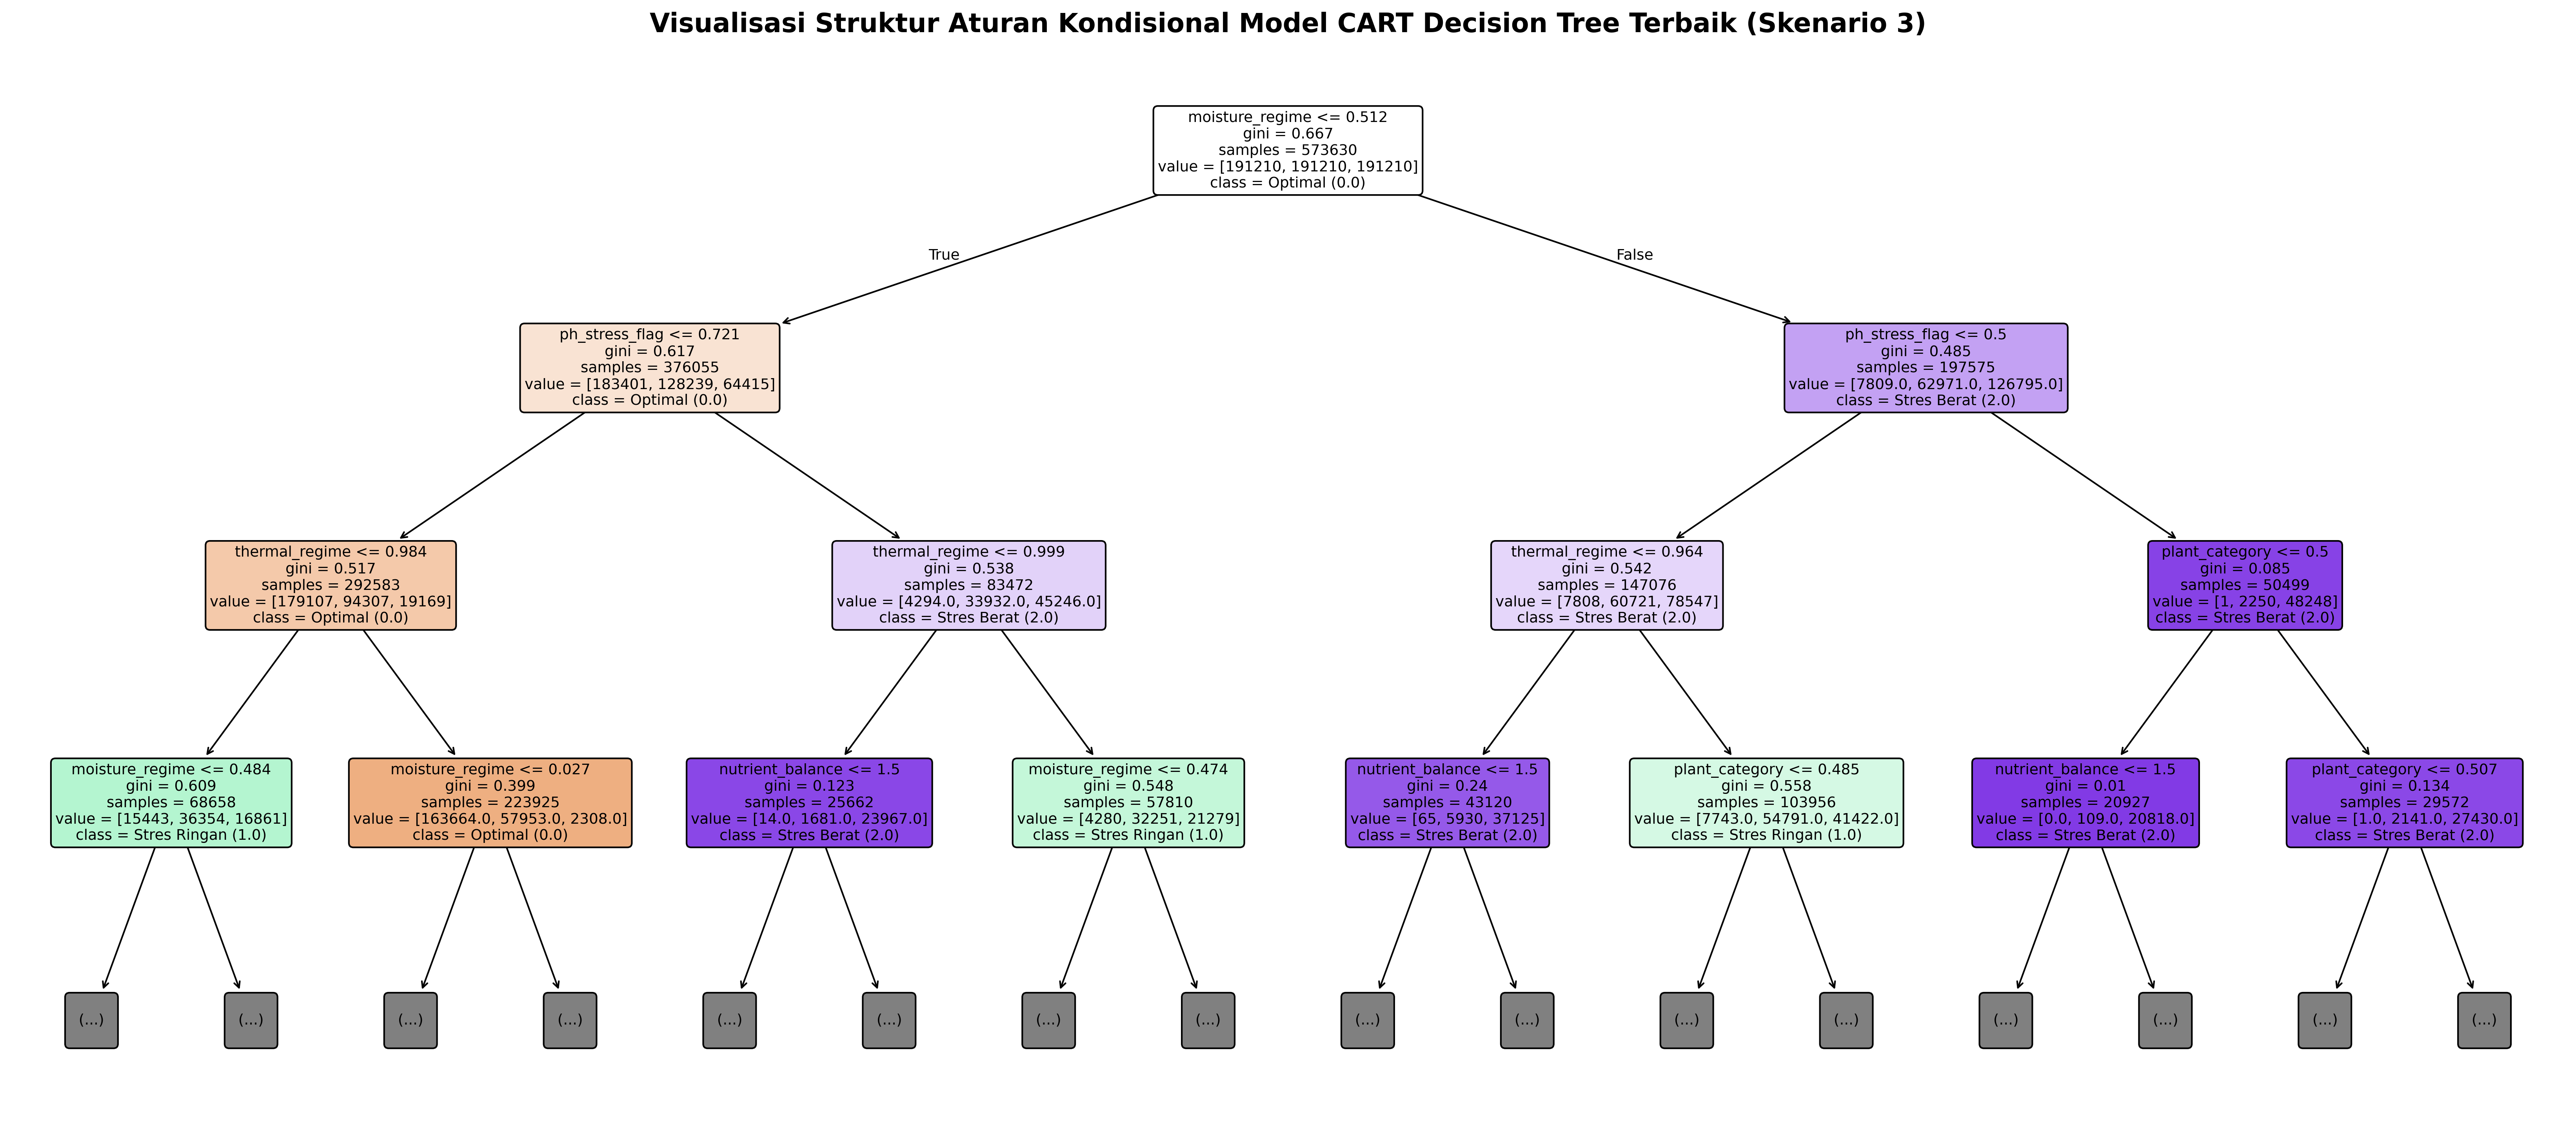

In [ ]:
# Cell 16: Visualisasi Struktur Aturan Decision Tree Terbaik (Skenario 3: Baseline + SMOTE)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Melatih ulang model terbaik secara khusus agar objeknya tidak tertimpa skenario lain
best_dt = DecisionTreeClassifier(max_depth=12, random_state=42)
best_dt.fit(X_train_smote, y_train_smote)  # Menggunakan data lengkap yang sudah di-SMOTE

# 2. Mengatur ukuran kanvas gambar (DPI tinggi agar teks tidak pecah saat di-zoom)
plt.figure(figsize=(28, 12), dpi=300)

# 3. Mendefinisikan penanda nama kelas target dalam format string
class_names_list = ['Optimal (0.0)', 'Stres Ringan (1.0)', 'Stres Berat (2.0)']

# 4. Memanggil fungsi plot_tree
# Catatan: max_depth dibatasi ke angka 3 agar pohon keputusan mudah dibaca dan muat di halaman paper.
# Jika max_depth dimasukkan angka 12 (penuh), grafiknya akan menjadi terlalu padat dan teksnya bertumpuk hitam.
plot_tree(
    best_dt,
    max_depth=3,                           # Batasan tingkat kedalaman untuk visualisasi artikel
    feature_names=X.columns.tolist(),      # Menggunakan seluruh nama fitur prediktor asli
    class_names=class_names_list,          # Menampilkan nama label kelas target
    filled=True,                           # Memberikan warna otomatis sesuai dominasi kelas di node
    rounded=True,                          # Mengubah sudut kotak aturan menjadi bulat agar rapi
    fontsize=9                             # Ukuran huruf di dalam kotak aturan
)

# 5. Menambahkan judul grafik visualisasi
plt.title("Visualisasi Struktur Aturan Kondisional Model CART Decision Tree Terbaik (Skenario 3)", fontsize=16, fontweight='bold')

# 6. Menyimpan hasil plot secara otomatis menjadi file gambar PNG berkualitas tinggi
# Gambar ini yang nantinya bisa langsung Anda insert ke dalam dokumen Word/AIP Paper Anda.
plt.savefig("visualisasi_decision_tree_terbaik.png", bbox_inches='tight', dpi=300)

# 7. Memunculkan grafik di dalam Jupyter Notebook
plt.show()